<a href="https://colab.research.google.com/github/espindolaleticia/cp2_mlam/blob/main/CP02_MLAM_pt02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 02 — Machine Learning
## Regressão Linear entre PIB e Índice ABCR

**Integrantes:** SUBSTITUIR PELOS NOMES E RM DOS ALUNOS  
**Data:** 07/10/2026

### Objetivo
Analisar a relação entre a atividade econômica brasileira, representada pelo **índice de volume do PIB**, e o fluxo de veículos nas rodovias, representado pelo **Índice ABCR Total**. Depois, será utilizado um modelo de **regressão linear** para estimar o Índice ABCR a partir do índice do PIB.

> As planilhas são carregadas diretamente do GitHub. Não é necessário fazer download nem upload dos arquivos para executar o notebook no Google Colab.

## 1. Fontes dos dados

Foram utilizadas as fontes indicadas no enunciado:

- **IBGE / SIDRA — Tabela 1620:** série encadeada do índice de volume trimestral, Brasil, **PIB a preços de mercado**, sem ajuste sazonal.  
  https://sidra.ibge.gov.br/tabela/1620
- **ABCR — Índice ABCR:** série histórica **original**, Brasil, **TOTAL**, número-índice.  
  https://melhoresrodovias.org.br/indice-abcr_2/
- **Enunciado do Checkpoint:**  
  https://github.com/prof-atritiack/CHECKPOINT_02_MLAM_2026_2

### Período utilizado
Foram considerados **20 anos completos, de 2006 a 2025**.

### Arquivos utilizados no notebook
As duas planilhas estão no repositório do grupo e são lidas diretamente pelo código:

- `dados/pib_ibge.xlsx`
- `dados/abcr_historico..xlsx`

Com isso, qualquer pessoa que abrir o notebook no Colab pode executar as células sem enviar os arquivos manualmente.

#Integrantes

-Felipe Mitsuo Takahashi Stephano RM570692

-Laura Godoy Callegari RM569181

-Letícia Araújo Espindola RM569308

-Mariana Dreset Carbollan 569207

-Milena de Aguiar Lopes Cardoso RM570599

## 2. Importação das bibliotecas

Serão utilizadas:

- `pandas` para organizar e tratar os dados;
- `matplotlib` para os gráficos;
- `scikit-learn` para a regressão linear e as métricas de avaliação;
- `requests` para carregar as planilhas armazenadas no GitHub.

In [ ]:
from io import BytesIO
import requests
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 3. Dados trimestrais do PIB

A planilha do PIB é carregada diretamente do GitHub. Para a análise será mantida somente a série **PIB a preços de mercado**, no período de 2006 a 2025.

In [ ]:
# URLs das planilhas no repositório
URL_PIB = "https://github.com/espindolaleticia/cp2_mlam/raw/refs/heads/main/dados/pib_ibge.xlsx"
URL_ABCR = "https://github.com/espindolaleticia/cp2_mlam/raw/refs/heads/main/dados/abcr_historico.xlsx"

def baixar_arquivo(url):
    resposta = requests.get(url, timeout=60)
    resposta.raise_for_status()
    return resposta.content

conteudo_pib = baixar_arquivo(URL_PIB)
conteudo_abcr = baixar_arquivo(URL_ABCR)

# A planilha do SIDRA possui cabeçalhos em mais de uma linha.
pib_raw = pd.read_excel(BytesIO(conteudo_pib), sheet_name="Tabela", header=None)

# Linha dos períodos, setores e valores do Brasil.
periodos = pib_raw.iloc[3].ffill()
setores = pib_raw.iloc[4]
valores = pib_raw.iloc[5]

selecao = setores.eq("PIB a preços de mercado")

pib_trimestral = pd.DataFrame({
    "Periodo": periodos[selecao].values,
    "PIB_indice_trimestral": pd.to_numeric(valores[selecao].values, errors="coerce")
})

extraido = pib_trimestral["Periodo"].astype(str).str.extract(r"(\d+)º trimestre\s+(\d{4})")
pib_trimestral["Trimestre"] = pd.to_numeric(extraido[0], errors="coerce")
pib_trimestral["Ano"] = pd.to_numeric(extraido[1], errors="coerce")

pib_trimestral = (
    pib_trimestral
    .dropna(subset=["Ano", "Trimestre", "PIB_indice_trimestral"])
    .query("2006 <= Ano <= 2025")
    .astype({"Ano": int, "Trimestre": int})
    [["Ano", "Trimestre", "PIB_indice_trimestral"]]
    .sort_values(["Ano", "Trimestre"])
    .reset_index(drop=True)
)

pib_trimestral.head(8)

,Ano,Trimestre,PIB_indice_trimestral
0,2006,1,128.1800
1,2006,2,132.1300
2,2006,3,136.7200
3,2006,4,136.3700
4,2007,1,134.8400
5,2007,2,140.7700
6,2007,3,144.7500
7,2007,4,145.4300


### 3.1 Validação do PIB

Cada ano deve possuir exatamente **4 trimestres** e o período deve ir de 2006 até 2025.

In [ ]:
contagem_pib = pib_trimestral.groupby("Ano").size()

print("Quantidade total de observações trimestrais:", len(pib_trimestral))
print("Primeiro ano:", pib_trimestral["Ano"].min())
print("Último ano:", pib_trimestral["Ano"].max())
print("Todos os anos possuem 4 trimestres?", (contagem_pib == 4).all())

contagem_pib.to_frame("Quantidade de trimestres").T

Quantidade total de observações trimestrais: 80
Primeiro ano: 2006
Último ano: 2025
Todos os anos possuem 4 trimestres? True


Ano,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Quantidade de trimestres,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4


## 4. Dados mensais do Índice ABCR

Na planilha da ABCR será utilizada a aba **(C) Original**, considerando **Brasil → TOTAL**, sem ajuste sazonal. Depois, serão mantidos somente os meses de 2006 a 2025.

In [ ]:
abcr_raw = pd.read_excel(BytesIO(conteudo_abcr), sheet_name="(C) Original", header=None)

# Na aba original, a primeira coluna contém as datas e a coluna 3 contém o TOTAL do Brasil.
abcr_mensal = pd.DataFrame({
    "Data": pd.to_datetime(abcr_raw.iloc[3:, 0], errors="coerce"),
    "ABCR_indice_mensal": pd.to_numeric(abcr_raw.iloc[3:, 3], errors="coerce")
}).dropna()

abcr_mensal["Ano"] = abcr_mensal["Data"].dt.year
abcr_mensal["Mes"] = abcr_mensal["Data"].dt.month

abcr_mensal = (
    abcr_mensal
    .query("2006 <= Ano <= 2025")
    .sort_values("Data")
    .reset_index(drop=True)
)

abcr_mensal.head(12)

,Data,ABCR_indice_mensal,Ano,Mes
0,2006-01-01,117.4844,2006,1
1,2006-02-01,100.1310,2006,2
2,2006-03-01,105.8320,2006,3
3,2006-04-01,104.4496,2006,4
4,2006-05-01,102.6991,2006,5
5,2006-06-01,97.7455,2006,6
6,2006-07-01,109.5875,2006,7
7,2006-08-01,106.0989,2006,8
8,2006-09-01,105.3876,2006,9
9,2006-10-01,108.5759,2006,10


### 4.1 Validação da ABCR

Cada ano deve possuir exatamente **12 meses** e o período deve ir de 2006 até 2025.

In [ ]:
contagem_abcr = abcr_mensal.groupby("Ano").size()

print("Quantidade total de observações mensais:", len(abcr_mensal))
print("Primeiro ano:", abcr_mensal["Ano"].min())
print("Último ano:", abcr_mensal["Ano"].max())
print("Todos os anos possuem 12 meses?", (contagem_abcr == 12).all())

contagem_abcr.to_frame("Quantidade de meses").T

Quantidade total de observações mensais: 240
Primeiro ano: 2006
Último ano: 2025
Todos os anos possuem 12 meses? True


Ano,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Quantidade de meses,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12


## 5. Transformação das séries para médias anuais

O enunciado pede uma única linha para cada ano:

- `PIB_indice`: média dos **4 índices trimestrais** do PIB;
- `ABCR_indice`: média dos **12 índices mensais** da ABCR.

A média é utilizada para colocar as duas séries na mesma periodicidade anual.

In [ ]:
pib_anual = (
    pib_trimestral
    .groupby("Ano", as_index=False)["PIB_indice_trimestral"]
    .mean()
    .rename(columns={"PIB_indice_trimestral": "PIB_indice"})
)

abcr_anual = (
    abcr_mensal
    .groupby("Ano", as_index=False)["ABCR_indice_mensal"]
    .mean()
    .rename(columns={"ABCR_indice_mensal": "ABCR_indice"})
)

print("PIB anual:")
display(pib_anual.head())

print("ABCR anual:")
display(abcr_anual.head())

PIB anual:


,Ano,PIB_indice
0,2006,133.3500
1,2007,141.4475
2,2008,148.6525
3,2009,148.4675
4,2010,159.6425


ABCR anual:


,Ano,ABCR_indice
0,2006,107.4897
1,2007,113.9859
2,2008,120.9087
3,2009,123.6021
4,2010,133.1206


## 6. Construção da base final

As duas tabelas anuais são unidas pela coluna `Ano`. Cada linha passa a representar o mesmo ano nos dois indicadores.

In [ ]:
base = pd.merge(pib_anual, abcr_anual, on="Ano", how="inner")
base = base.sort_values("Ano").reset_index(drop=True)

base

,Ano,PIB_indice,ABCR_indice
0,2006,133.3500,107.4897
1,2007,141.4475,113.9859
2,2008,148.6525,120.9087
3,2009,148.4675,123.6021
4,2010,159.6425,133.1206
5,2011,165.9850,141.4430
6,2012,169.1750,147.9720
7,2013,174.2600,153.5890
8,2014,175.1400,157.2332
9,2015,168.9275,154.2482


### 6.1 Verificações finais da base

Antes da análise, são verificados:

- total de 20 anos;
- período de 2006 a 2025;
- ausência de valores nulos;
- ausência de anos duplicados.

In [ ]:
print("Dimensão da base:", base.shape)
print("Período:", base["Ano"].min(), "a", base["Ano"].max())
print("Valores nulos por coluna:")
print(base.isnull().sum())
print("Anos duplicados:", base["Ano"].duplicated().sum())

assert base.shape == (20, 3), "A base deveria ter 20 linhas e 3 colunas."
assert base["Ano"].min() == 2006 and base["Ano"].max() == 2025
assert base.isnull().sum().sum() == 0
assert base["Ano"].duplicated().sum() == 0

print()
print("Validação concluída: a base está pronta para análise.")

Dimensão da base: (20, 3)
Período: 2006 a 2025
Valores nulos por coluna:
Ano            0
PIB_indice     0
ABCR_indice    0
dtype: int64
Anos duplicados: 0

Validação concluída: a base está pronta para análise.


### 6.2 Gerar a base anual em CSV

Esta célula cria `base_anual_2006_2025.csv` no ambiente do Colab. O arquivo pode ser incluído no repositório junto com as bases originais.

In [ ]:
base.to_csv("base_anual_2006_2025.csv", index=False)
print("Arquivo criado: base_anual_2006_2025.csv")

Arquivo criado: base_anual_2006_2025.csv


## 7. Análise da relação entre PIB e ABCR

Primeiro é construído um gráfico de dispersão, conforme solicitado. O eixo horizontal representa o índice do PIB e o eixo vertical representa o Índice ABCR.

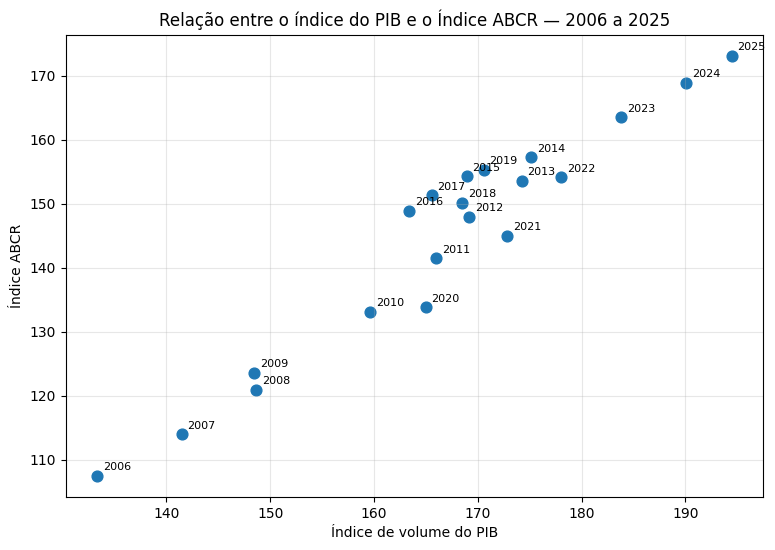

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(base["PIB_indice"], base["ABCR_indice"], s=60)

for _, linha in base.iterrows():
    plt.annotate(
        str(int(linha["Ano"])),
        (linha["PIB_indice"], linha["ABCR_indice"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Índice de volume do PIB")
plt.ylabel("Índice ABCR")
plt.title("Relação entre o índice do PIB e o Índice ABCR — 2006 a 2025")
plt.grid(alpha=0.3)
plt.show()

### 7.1 Correlação de Pearson

A correlação mede a intensidade e a direção da associação linear entre as duas variáveis. Ela varia de -1 a +1.

> Uma correlação alta **não comprova causalidade**. Ela indica associação entre as variáveis, não que uma seja necessariamente a causa da outra.

In [ ]:
correlacao = base["PIB_indice"].corr(base["ABCR_indice"])
print(f"Correlação de Pearson: {correlacao:.4f}")

if correlacao >= 0.7:
    interpretacao = "forte e positiva"
elif correlacao >= 0.3:
    interpretacao = "moderada e positiva"
elif correlacao > -0.3:
    interpretacao = "fraca"
elif correlacao > -0.7:
    interpretacao = "moderada e negativa"
else:
    interpretacao = "forte e negativa"

print("Interpretação:", interpretacao)

Correlação de Pearson: 0.9641
Interpretação: forte e positiva


**Interpretação obtida com esta base:** a correlação é aproximadamente **0.9641**, indicando uma associação linear **forte e positiva** entre os dois índices no período analisado. Isso significa que anos com maior índice de volume do PIB tendem também a apresentar maior Índice ABCR. Mesmo assim, esse resultado não demonstra relação de causa e efeito.

## 8. Separação entre treino e teste

Conforme o enunciado:

- `X`: `PIB_indice`;
- `y`: `ABCR_indice`;
- treino: **primeiros 16 anos**;
- teste: **últimos 4 anos**;
- ordem cronológica mantida, sem embaralhamento.

Assim, o treino corresponde a **2006–2021** e o teste a **2022–2025**.

In [ ]:
treino = base.iloc[:16].copy()
teste = base.iloc[16:].copy()

X_train = treino[["PIB_indice"]]
y_train = treino["ABCR_indice"]

X_test = teste[["PIB_indice"]]
y_test = teste["ABCR_indice"]

print("Anos de treino:", treino["Ano"].tolist())
print("Anos de teste:", teste["Ano"].tolist())

Anos de treino: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Anos de teste: [2022, 2023, 2024, 2025]


## 9. Treinamento da regressão linear

O modelo procura uma reta no formato:

\[
ABCR = a + b 	imes PIB
\]

em que `a` é o intercepto e `b` é o coeficiente associado ao PIB.

In [ ]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print(f"Coeficiente (b): {modelo.coef_[0]:.6f}")
print(f"Intercepto (a): {modelo.intercept_:.6f}")
print(f"Equação aproximada: ABCR = {modelo.intercept_:.4f} + {modelo.coef_[0]:.4f} × PIB")

Coeficiente (b): 1.214533
Intercepto (a): -56.785600
Equação aproximada: ABCR = -56.7856 + 1.2145 × PIB


Nesta execução, a equação ajustada com os 16 anos de treino é aproximadamente:

\[
ABCR = -56.7856 + 1.2145 	imes PIB
\]

O coeficiente positivo é coerente com a correlação positiva encontrada anteriormente.

## 10. Avaliação no conjunto de teste

São utilizadas as três métricas solicitadas:

- **MAE (Mean Absolute Error):** erro absoluto médio. Indica, em média, quantos pontos de índice separam previsão e valor real. Quanto menor, melhor.
- **MSE (Mean Squared Error):** média dos erros elevados ao quadrado. Penaliza mais fortemente erros grandes. Quanto menor, melhor.
- **R²:** mede quanto da variação dos valores do conjunto de teste é explicada pelo modelo. Valores maiores indicam maior capacidade explicativa; o enunciado não exige R² mínimo.

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 4.9489
MSE: 25.9502
R²: 0.4849


### Interpretação das métricas

Com os dados utilizados, foram obtidos aproximadamente:

- **MAE = 4.9489:** as previsões ficaram, em média, cerca de **4.95 pontos do Índice ABCR** distantes dos valores observados.
- **MSE = 25.9502:** como os erros são elevados ao quadrado, essa métrica dá maior peso aos desvios maiores.
- **R² = 0.4849:** no conjunto de teste, o modelo explica aproximadamente **48.5%** da variação do Índice ABCR observada entre 2022 e 2025.

O resultado indica que o PIB possui capacidade explicativa relevante, mas **não é suficiente sozinho** para reproduzir perfeitamente o fluxo de veículos. O tráfego também pode ser influenciado por outros fatores que não fazem parte deste modelo.

## 11. Valores observados × previstos

A tabela abaixo compara o valor real do Índice ABCR com a estimativa produzida pelo modelo nos quatro anos reservados para teste.

In [ ]:
resultados = teste[["Ano", "PIB_indice", "ABCR_indice"]].copy()
resultados["ABCR_previsto"] = y_pred
resultados["Erro"] = resultados["ABCR_indice"] - resultados["ABCR_previsto"]
resultados["Erro_absoluto"] = resultados["Erro"].abs()

resultados

,Ano,PIB_indice,ABCR_indice,ABCR_previsto,Erro,Erro_absoluto
16,2022,178.0475,154.1235,159.4589,-5.3354,5.3354
17,2023,183.8175,163.4908,166.4667,-2.9759,2.9759
18,2024,190.1025,168.8758,174.1001,-5.2243,5.2243
19,2025,194.4500,173.1204,179.3803,-6.2598,6.2598


### 11.1 Gráfico: real × previsto

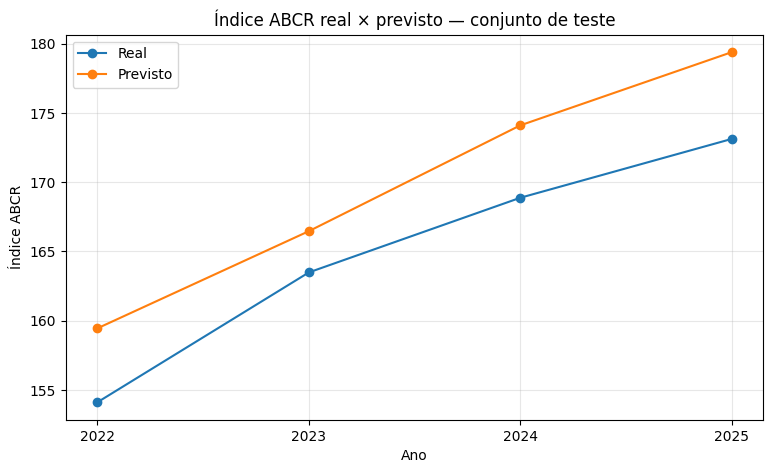

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(resultados["Ano"], resultados["ABCR_indice"], marker="o", label="Real")
plt.plot(resultados["Ano"], resultados["ABCR_previsto"], marker="o", label="Previsto")
plt.xticks(resultados["Ano"])
plt.xlabel("Ano")
plt.ylabel("Índice ABCR")
plt.title("Índice ABCR real × previsto — conjunto de teste")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 12. Visualização da reta de regressão

O gráfico a seguir mostra os dados de treino, os dados de teste e a reta aprendida pelo modelo. Ele ajuda a visualizar como a regressão extrapola a relação observada durante o treinamento para os quatro anos finais.

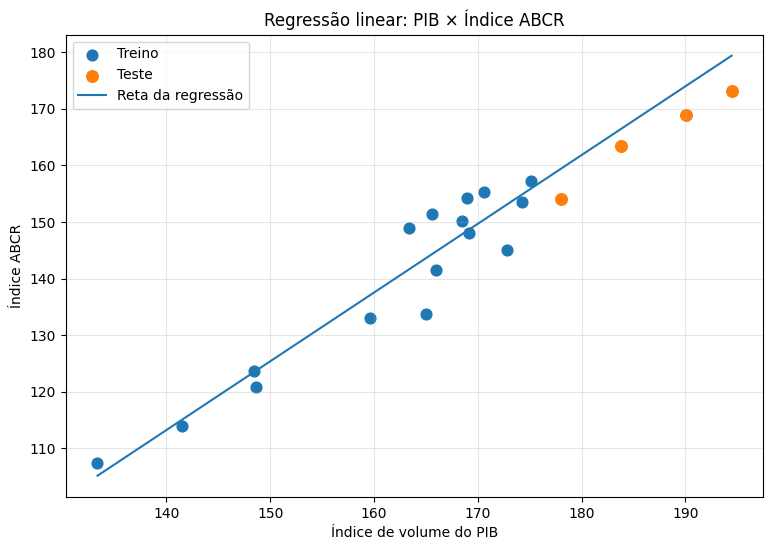

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(treino["PIB_indice"], treino["ABCR_indice"], label="Treino", s=60)
plt.scatter(teste["PIB_indice"], teste["ABCR_indice"], label="Teste", s=70)

x_reta = pd.DataFrame({"PIB_indice": [base["PIB_indice"].min(), base["PIB_indice"].max()]})
y_reta = modelo.predict(x_reta)
plt.plot(x_reta["PIB_indice"], y_reta, label="Reta da regressão")

plt.xlabel("Índice de volume do PIB")
plt.ylabel("Índice ABCR")
plt.title("Regressão linear: PIB × Índice ABCR")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 13. Conclusão

A análise dos anos de **2006 a 2025** mostrou uma correlação de aproximadamente **0.9641** entre o índice de volume do PIB e o Índice ABCR, caracterizando uma associação linear forte e positiva no período analisado.

O modelo foi treinado com os anos de **2006 a 2021** e testado em **2022 a 2025**, respeitando a ordem cronológica exigida. No teste, foram obtidos **MAE = 4.9489**, **MSE = 25.9502** e **R² = 0.4849**. O MAE indica um erro médio de aproximadamente **4.95 pontos de índice** nas previsões. O R² mostra que o modelo conseguiu explicar parte importante da variação observada nos quatro anos finais, mas ainda existem diferenças entre os valores reais e previstos.

Portanto, os resultados sugerem que existe uma relação relevante entre atividade econômica e fluxo de veículos, porém o **PIB sozinho não explica completamente o comportamento do Índice ABCR**. Outros fatores — como preços dos combustíveis, mudanças no transporte de cargas, mobilidade, infraestrutura rodoviária e eventos econômicos excepcionais — podem influenciar o fluxo de veículos.

Por fim, a correlação encontrada **não deve ser interpretada como prova de causalidade**.

## 14. Dificuldades encontradas e soluções adotadas

### Dificuldade 1 — Periodicidades diferentes
O PIB é disponibilizado trimestralmente, enquanto o Índice ABCR é mensal.

**Solução:** calcular a média dos quatro trimestres do PIB e a média dos doze meses da ABCR para obter uma linha por ano.

### Dificuldade 2 — Seleção das séries
As planilhas possuem informações que não entram na análise, como outros setores do PIB, veículos leves e pesados separadamente e séries diferentes da ABCR.

**Solução:** utilizar apenas **PIB a preços de mercado** e **Brasil → TOTAL → Série original**.

### Dificuldade 3 — Execução do notebook por outras pessoas
Se os arquivos fossem enviados manualmente para o Colab, cada pessoa teria de repetir esse processo.

**Solução:** manter as planilhas no GitHub e carregá-las diretamente pelo código. Assim, basta abrir o notebook e executar as células na ordem.